Импортируем необходимые библиотеки:

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import seaborn as sns

Читаем данные:

In [ ]:
data = pd.read_csv('../data_ml6/data_ford_price.csv',sep = ';')
data.head()

,price,year,condition,cylinders,odometer,title_status,transmission,drive,size,lat,long,weather
0,43900,2016,4,6,43500,clean,automatic,4wd,full-size,"36,4715","-82,4834",59.0
1,15490,2009,2,8,98131,clean,automatic,4wd,full-size,"40,468826","-74,281734",52.0
2,2495,2002,2,8,201803,clean,automatic,4wd,full-size,"42,477134","-82,949564",45.0
3,1300,2000,1,8,170305,rebuilt,automatic,4wd,full-size,"40,764373","-82,349503",49.0
4,13865,2010,3,8,166062,clean,automatic,4wd,NaN,"49,210949","-123,11472",NaN


Заменяем запятую на точку в признаках широты и долготы:

In [38]:
def fix_lat_long(df: pd.DataFrame, lat_col: str = "lat", long_col: str = "long") -> pd.DataFrame:
    """
    Заменяет запятую на точку в указанных столбцах и конвертирует их в float.
    
    Параметры:
        df: входной DataFrame
        lat_col: имя столбца с широтой
        long_col: имя столбца с долготой
    
    Возвращает:
        DataFrame с исправленными столбцами (возвращается копия, исходный df не меняется)
    """
    df_fixed = df.copy()
    
    for col in [lat_col, long_col]:
        if col not in df_fixed.columns:
            raise ValueError(f"Столбец '{col}' не найден в DataFrame")
        
        # Приводим к строке, заменяем запятую на точку, конвертируем в float
        df_fixed[col] = (
            df_fixed[col]
            .astype(str)
            .str.replace(',', '.', regex=False)
            .astype(float, errors='ignore')  # если останется не-число, останется как есть
        )
        
        # Дополнительная очистка: если после replace всё ещё есть не-числа, превращаем в NaN
        df_fixed[col] = pd.to_numeric(df_fixed[col], errors='coerce')
    
    return df_fixed

data = fix_lat_long(data)

Так как мы строим модель линейной регрессии, выделяем числовые признаки и удаляем строки с пропусками:

In [39]:
data = data[['price','year', 'cylinders', 'odometer', 'lat', 'long', 'weather']]
data.dropna(inplace = True)

Построим тепловую матрицу корреляции для поиска мультиколлениарности:

<Axes: >

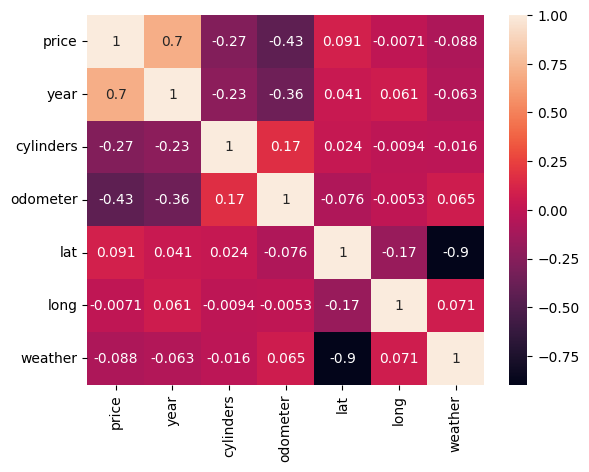

In [40]:
sns.heatmap(data.corr(), annot=True)

Присутствует сильная зависимость между ```lat``` и ```weather```. Удалим ```lat```, так как этот признак, в отличие от ```weather```, необходимо округлять.

In [41]:
data.drop('lat', axis = 1, inplace = True)

Разделяем данные на целевую переменную и остальные признаки

In [42]:
y = data['price']
x = data.drop(columns='price')

Разделим выборку на тренировочную и тестовую в соотношении 80/20:

In [43]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

RFE на обучающей выборке:

In [44]:
estimator = LinearRegression()
selector = RFE(estimator, n_features_to_select=3, step=1)
selector = selector.fit(X_train, y_train)
 
selected_features = selector.get_feature_names_out()
print("Отобранные признаки:", selected_features)

Отобранные признаки: ['year' 'cylinders' 'weather']


На полученных 3 признаках обучим линейную регрессию и получим оценку качества MAE:

In [53]:
X_train_rfe = X_train[selected_features]
X_test_rfe = X_test[selected_features]

model = LinearRegression()
model.fit(X_train_rfe, y_train)
y_pred_rfe  = model.predict(X_test_rfe)

mae_rfe = mean_absolute_error(y_test, y_pred_rfe)
print(f'MAE (RFE): {mae_rfe:.3f}')

MAE (RFE): 5310.767


---

SelectKBest на обучающей выборке:

In [46]:
selector = SelectKBest(f_regression, k=3)
selector.fit(X_train, y_train)
 
selected_features2 = selector.get_feature_names_out()
print("Отобранные признаки:", selected_features2)

Отобранные признаки: ['year' 'cylinders' 'odometer']


Также на 3 признаках обучим линейную регрессию и получим оценку качества MAE:

In [54]:
X_train_skb = X_train[selected_features2]
X_test_skb = X_test[selected_features2]

model2 = LinearRegression()
model2.fit(X_train_skb, y_train)
y_pred_skb  = model2.predict(X_test_skb)

mae_skb  = mean_absolute_error(y_test, y_pred_skb)
print(f'MAE (SelectKBest): {mae_skb:.3f}')

MAE (SelectKBest): 4925.458


>**ВЫВОДЫ:**

Метод RFE отбора признаков показал налиучший результат на тестовой выборке по сравнению с SelectKBest.

Метрика MAE (RFE): 5310.767 > MAE (SelectKBest): 4925.458